# Activities, peaks, and exposure statistics

This example shows how to:

- Load a 1D time series (CPC total number concentration)
- Inspect main and extra data
- Define simple time segments (activities)
- Detect peaks using `Peak_finder`
- Plot total concentration with activity shading
- Summarize activities and compute exposure metrics with `summarize_exposure`

In [ ]:
import matplotlib.pyplot as plt
import aerosoltools as at

## Load CPC sample data

Here we load a sample CPC file from the test data folder.
Adjust the path if you keep example data elsewhere.

In [2]:
filename = r"..\..\tests\data\Sample_CPC_AIM.txt"
cpc = at.Load_CPC_file(filename,extra_data=True)

## Inspect metadata and extra data

The loader returns an `Aerosol1D` instance with:

- `.data` – main time series + activity masks
- `.extra_data` – optional additional channels (environmental, meta, etc.)
- `.metadata` – instrument, unit, etc.

In [26]:
print("Metadata:\n", cpc.metadata)
print("\nMain columns:", list(cpc.data.columns))
print("Extra-data columns:", list(cpc.extra_data.columns))

Metadata:
 {'instrument': 'CPC', 'serial_number': '06160001 ', 'unit': 'cm$^{-3}$'}

Main columns: ['Total_conc', 'All data']
Extra-data columns: ['Sample Length (s)', 'Averaging Interval (s)', 'Title', 'Instrument ID', 'Instrument Errors', 'Mean(#/cm³)', 'Min(#/cm³)', 'Max(#/cm³)', 'Std. Dev.(#/cm³)', 'Comments']


You can access data in the main DataFrame via the `.data` property of the defined cpc variable:

In [27]:
cpc.data


,Total_conc,All data
Datetime,,
2023-08-14 11:14:29,1468,True
2023-08-14 11:14:30,1459,True
2023-08-14 11:14:31,1437,True
2023-08-14 11:14:32,1462,True
2023-08-14 11:14:33,1481,True
...,...,...
2023-08-14 11:20:49,1293,True
2023-08-14 11:20:50,1307,True
2023-08-14 11:20:51,1311,True


Similarly, you can access any additional data columns extracted from the raw data via the `.extra_data` property:

In [28]:

cpc.extra_data

,Sample Length (s),Averaging Interval (s),Title,Instrument ID,Instrument Errors,Mean(#/cm³),Min(#/cm³),Max(#/cm³),Std. Dev.(#/cm³),Comments
Datetime,,,,,,,,,,
2023-08-14 11:14:29,00:01,1,,3007-06160001 3.1,NaN,1468,1468,1468,0,NaN
2023-08-14 11:14:30,00:01,1,,3007-06160001 3.1,NaN,1459,1459,1459,0,NaN
2023-08-14 11:14:31,00:01,1,,3007-06160001 3.1,NaN,1437,1437,1437,0,NaN
2023-08-14 11:14:32,00:01,1,,3007-06160001 3.1,NaN,1462,1462,1462,0,NaN
2023-08-14 11:14:33,00:01,1,,3007-06160001 3.1,NaN,1481,1481,1481,0,NaN
...,...,...,...,...,...,...,...,...,...,...
2023-08-14 11:20:49,00:01,1,,3007-06160001 3.1,NaN,1293,1293,1293,0,NaN
2023-08-14 11:20:50,00:01,1,,3007-06160001 3.1,NaN,1307,1307,1307,0,NaN
2023-08-14 11:20:51,00:01,1,,3007-06160001 3.1,NaN,1311,1311,1311,0,NaN


## Plot total concentration

Use `plot_total_conc()` to quickly visualize the time series.

(<Figure size 1000x500 with 1 Axes>,
 <Axes: xlabel='Time', ylabel='dN, cm$^{-3}$'>)

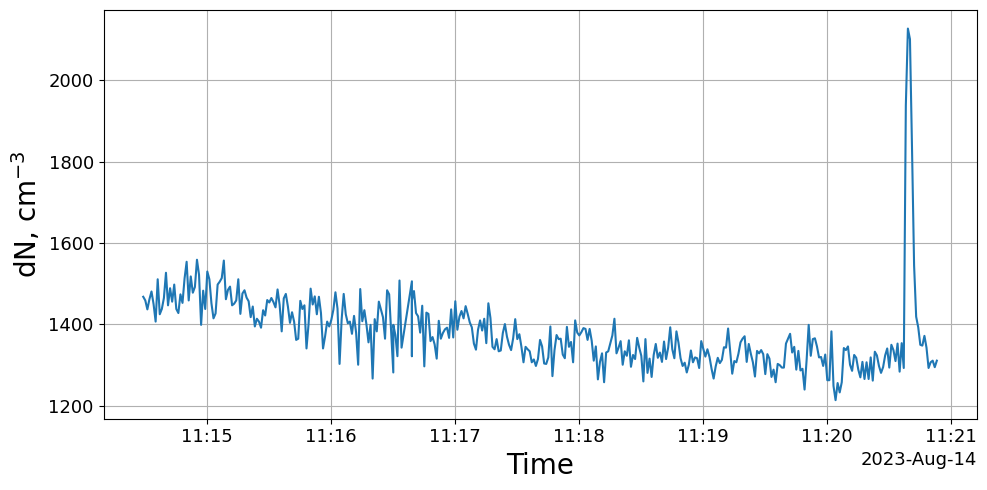

In [3]:
cpc.plot_total_conc()

## Detect peaks with `Peak_finder`

`Peak_finder` flags time steps where the signal exceeds a rolling baseline
by more than `ratio * rolling_std`. The resulting mask is stored as the
`"Peak"` activity.

In [5]:
cpc.Peak_finder(window=15, ratio=2.5, method="median")
cpc.activities

['All data', 'Peak']

We can also mark specific activities based on timestamps:

In [11]:
activity_periods= {
    "initial_phase": [
        ("2023-08-14 11:14:00", "2023-08-14 11:17:00"),
        ("2023-08-14 11:17:30", "2023-08-14 11:18:00")],
    "second_phase": [
        ("2023-08-14 11:19:00", "2023-08-14 11:20:00")]
}
cpc.mark_activities(activity_periods)

## Plot with activity shading

We can overlay activities (including the automatically created `"Peak"` mask)
on top of the total concentration time series.

(<Figure size 1000x500 with 1 Axes>,
 <Axes: xlabel='Time', ylabel='dN, cm$^{-3}$'>)

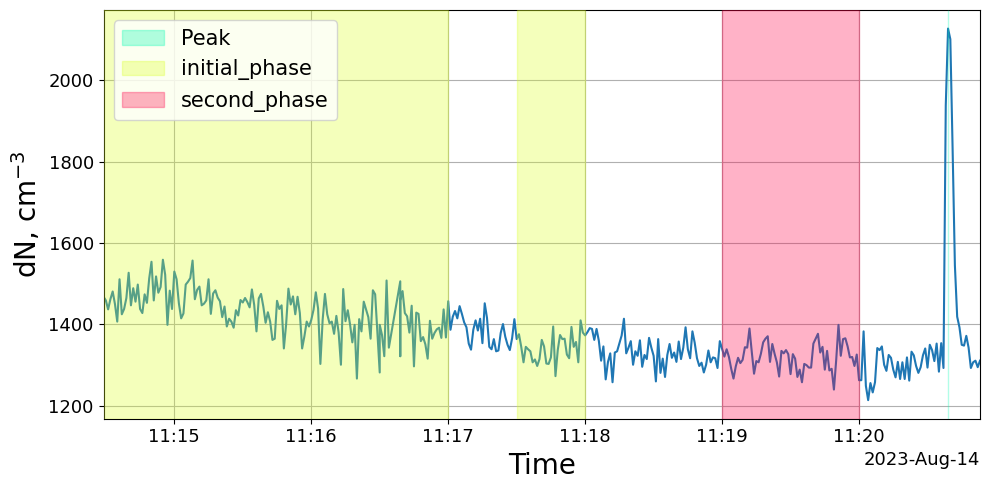

In [12]:
cpc.plot_total_conc(mark_activities=True)

## Summarize activities

`summarize_activities()` reports basic descriptive statistics per activity,
including duration, mean, median, and number of samples.

In [13]:
cpc.summarize_activities()


Summary of total concentration per activity:

+--------------------+----------+--------+---------------+--------------+
|    Metric/Field    | All data |  Peak  | initial_phase | second_phase |
+--------------------+----------+--------+---------------+--------------+
|   Duration (min)   |  6.417   | 0.017  |     3.05      |    1.017     |
|  Duration (HH:MM)  |  00:06   | 00:00  |     00:03     |    00:01     |
|  Min (cm$^{-3}$)   |  1214.0  | 2127.0 |    1267.0     |    1240.0    |
|  Max (cm$^{-3}$)   |  2127.0  | 2127.0 |    1559.0     |    1399.0    |
|  Mean (cm$^{-3}$)  | 1379.339 | 2127.0 |   1417.346    |   1319.869   |
| Median (cm$^{-3}$) |  1364.0  | 2127.0 |    1425.0     |    1320.0    |
|  Std (cm$^{-3}$)   |  94.659  |  nan   |    62.829     |    33.21     |
|     N samples      |   384    |   1    |      182      |      61      |
+--------------------+----------+--------+---------------+--------------+


,Segment,Duration (min),Duration (HH:MM),Min (cm$^{-3}$),Max (cm$^{-3}$),Mean (cm$^{-3}$),Median (cm$^{-3}$),Std (cm$^{-3}$),N samples
0,All data,6.417,00:06,1214.0,2127.0,1379.339,1364.0,94.659,384
1,Peak,0.017,00:00,2127.0,2127.0,2127.000,2127.0,NaN,1
2,initial_phase,3.050,00:03,1267.0,1559.0,1417.346,1425.0,62.829,182
3,second_phase,1.017,00:01,1240.0,1399.0,1319.869,1320.0,33.210,61


## Exposure summary for PNC

Finally, we use `summarize_exposure` on the `Aerosol1D` object to compute
exposure metrics for total number concentration (PNC):

- duration, mean, percentiles
- time above a long-term limit
- short-term (window-based) exceedances
- an 8-hour TWA (by default)

In [14]:
exp = cpc.summarize_exposure(
    metric="PNC",           # use total_concentration
    activity="All data",    # summarize whole record
    background=None,        # assume zero background outside the record
    exposure_hours=8.0,     # Set how long a worker was exposed to the measured concentration
    short_limit=1.0,        # Short term exposure limit for the given metric (if available)
    long_limit=1.0,         # long term or 8hr exposure limit for the given metric
    short_window="15min",   # Length of short term exposures to identify
)
exp


Exposure summary for activity 'All data' and metric 'PNC' (cm$^{-3}$):

+--------------------------------------------+-----------+
|                   Field                    |   Value   |
+--------------------------------------------+-----------+
|                   Metric                   |    PNC    |
|                    Unit                    | cm$^{-3}$ |
|                  Samples                   |    384    |
|                Duration_min                |   6.42    |
|               Duration_HH:MM               |   00:06   |
|                    Mean                    | 1379.018  |
|                    Std                     |  94.659   |
|                   Median                   |  1364.0   |
|                    Max                     |  2127.0   |
|                  Seg_TWA                   | 1379.018  |
|                 Window_TWA                 | 1379.018  |
|             Window_TWA_window              |    8h     |
|                Short_limit              

,Segment,Metric,Unit,Samples,Duration_min,Duration_HH:MM,Mean,Std,Median,Max,...,Short_limit_exceedance_fraction,Short_limit_fullwindow_exceedance_min,Short_limit_fullwindow_exceedance_episodes,Long_limit,Long_limit_exceeded,Long_limit_exceedance_min,C95,C99,IQR,Peaks
0,All data,PNC,cm$^{-3}$,384,6.42,00:06,1379.018,94.659,1364.0,2127.0,...,1.0,0.02,1,1.0,True,6.42,1503.95,1605.24,107.25,1
